In [2]:
import pandas as pd

# Load datasets
sentiment_df = pd.read_csv("fear_greed_index.csv")      # Bitcoin Market Sentiment
trades_df = pd.read_csv("historical_data.csv") # Hyperliquid Trader Data


In [3]:

# Shape
print("Sentiment shape:", sentiment_df.shape)
print("Trades shape:", trades_df.shape)

# Missing values
print("\nMissing values (Sentiment):\n", sentiment_df.isna().sum())
print("\nMissing values (Trades):\n", trades_df.isna().sum())

# Duplicates
print("\nDuplicate rows (Sentiment):", sentiment_df.duplicated().sum())
print("Duplicate rows (Trades):", trades_df.duplicated().sum())


Sentiment shape: (2644, 4)
Trades shape: (211224, 16)

Missing values (Sentiment):
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values (Trades):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows (Sentiment): 0
Duplicate rows (Trades): 0


In [5]:
sentiment_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [8]:
trades_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [9]:
# Standardize column names for easier coding
trades_df.columns = (
    trades_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

sentiment_df.columns = (
    sentiment_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(trades_df.columns)
print(sentiment_df.columns)


Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [14]:
# Parse timestamps (day-first)
trades_df["timestamp_ist"] = pd.to_datetime(
    trades_df["timestamp_ist"], format="mixed", dayfirst=True, errors="coerce"
)
trades_df["date"] = trades_df["timestamp_ist"].dt.date
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"]).dt.date

In [15]:

# Merge
merged_df = trades_df.merge(
    sentiment_df[["date", "classification"]],
    on="date",
    how="left"
)

In [16]:
print(merged_df["classification"].value_counts())
print(merged_df["date"].min(), "→", merged_df["date"].max())


classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64
2023-05-01 → 2025-05-01


In [17]:
# Drop unmatched sentiment rows (only 6 in your case)
merged_df = merged_df.dropna(subset=["classification"])

In [18]:
# Daily PnL per trader
daily_pnl = merged_df.groupby(["account", "date"])["closed_pnl"].sum().reset_index()

# Win rate
merged_df["win"] = merged_df["closed_pnl"] > 0
win_rate = merged_df.groupby("account")["win"].mean().reset_index(name="win_rate")

# Avg trade size (USD)
avg_trade_size = merged_df.groupby("account")["size_usd"].mean().reset_index()

# Trades per day
trades_per_day = merged_df.groupby("date").size().reset_index(name="num_trades")

# Long / Short ratio
long_short = (
    merged_df.groupby(["date", "side"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
long_short["long_short_ratio"] = long_short.get("buy", 0) / long_short.get("sell", 1)


Datasets were cleaned, timestamps standardized to daily granularity, and sentiment labels merged. Key behavioral and performance metrics were engineered, including daily PnL, win rate, trade size, trade frequency, and long/short ratios. Leverage analysis was excluded due to missing leverage data in the source dataset.

In [22]:
# ✅ Part B — Analysis
# 1️⃣ Fear vs Greed Performance

def map_regime(x):
    if x in ["Extreme Fear", "Fear"]:
        return "Fear"
    elif x in ["Greed", "Extreme Greed"]:
        return "Greed"
    else:
        return "Neutral"

merged_df["sentiment_regime"] = merged_df["classification"].apply(map_regime)


📊 PnL & Win Rate by Regime

In [23]:
perf_by_regime = (
    merged_df.groupby("sentiment_regime")
    .agg(
        avg_pnl=("closed_pnl", "mean"),
        median_pnl=("closed_pnl", "median"),
        win_rate=("win", "mean"),
        trades=("closed_pnl", "count")
    )
    .reset_index()
)

perf_by_regime


,sentiment_regime,avg_pnl,median_pnl,win_rate,trades
0,Fear,49.212077,0.0,0.407871,83237
1,Greed,53.882281,0.0,0.420311,90295
2,Neutral,34.307718,0.0,0.396991,37686


2️⃣ Behavior Change by Sentiment

In [24]:
behavior_by_regime = (
    merged_df.groupby("sentiment_regime")
    .agg(
        avg_trade_size_usd=("size_usd", "mean"),
        trades_per_day=("date", "nunique")
    )
    .reset_index()
)

behavior_by_regime


,sentiment_regime,avg_trade_size_usd,trades_per_day
0,Fear,7182.011019,105
1,Greed,4574.424490,307
2,Neutral,4782.732661,67


3️⃣ Trader Segments
Segment A: Frequent vs Infrequent Traders

In [28]:
# Frequent vs Infrequent Traders

trade_counts = merged_df.groupby("account").size().reset_index(name="num_trades")

threshold = trade_counts["num_trades"].quantile(0.75)
frequent_traders = trade_counts[trade_counts["num_trades"] >= threshold]["account"]

merged_df["frequency_segment"] = merged_df["account"].apply(
    lambda x: "Frequent" if x in set(frequent_traders) else "Infrequent"
)


In [26]:
# Segment B: Consistent Winners vs Inconsistent
pnl_stats = merged_df.groupby("account")["closed_pnl"].agg(["mean", "std"]).reset_index()

median_pnl = pnl_stats["mean"].median()

winners = pnl_stats[pnl_stats["mean"] > median_pnl]["account"]
merged_df["winner_segment"] = merged_df["account"].apply(
    lambda x: "Consistent Winner" if x in set(winners) else "Inconsistent"
)


In [ ]:
# high leverage vs low leverage traders
# --- Step 1: Compute average trade size per trader (proxy for leverage/risk) ---
risk_proxy = (
    merged_df
    .groupby("account")["size_usd"]
    .mean()
    .reset_index(name="avg_trade_size_usd")
)

# --- Step 2: Segment traders into High, Medium, Low Risk (Leverage Proxy) ---
q75 = risk_proxy["avg_trade_size_usd"].quantile(0.75)
q25 = risk_proxy["avg_trade_size_usd"].quantile(0.25)

def risk_segment(x):
    if x >= q75:
        return "High Risk (Leverage Proxy)"
    elif x <= q25:
        return "Low Risk (Leverage Proxy)"
    else:
        return "Medium Risk"

risk_proxy["risk_segment"] = risk_proxy["avg_trade_size_usd"].apply(risk_segment)

# Merge segment info back into main dataframe
merged_df = merged_df.merge(risk_proxy[["account", "risk_segment"]], on="account", how="left")

# --- Step 3: Compute performance metrics by sentiment regime and risk segment ---
segment_perf = (
    merged_df
    .groupby(["sentiment_regime", "risk_segment"])
    .agg(
        avg_pnl=("closed_pnl", "mean"),
        win_rate=("win", "mean"),
        num_trades=("closed_pnl", "count")
    )
    .reset_index()
)

# --- Step 4: Display results ---
print(segment_perf)


  sentiment_regime                risk_segment     avg_pnl  win_rate  \
0             Fear  High Risk (Leverage Proxy)  112.788173  0.404114   
1             Fear   Low Risk (Leverage Proxy)    1.204184  0.378065   
2             Fear                 Medium Risk   51.334469  0.437838   
3            Greed  High Risk (Leverage Proxy)   54.288807  0.323722   
4            Greed   Low Risk (Leverage Proxy)   23.685167  0.408014   
5            Greed                 Medium Risk  120.990567  0.496485   
6          Neutral  High Risk (Leverage Proxy)   88.062213  0.457302   
7          Neutral   Low Risk (Leverage Proxy)    1.935624  0.341494   
8          Neutral                 Medium Risk   52.989250  0.443986   

   num_trades  
0       21343  
1       29688  
2       32206  
3       12208  
4       53905  
5       24182  
6        6265  
7       18094  
8       13327  


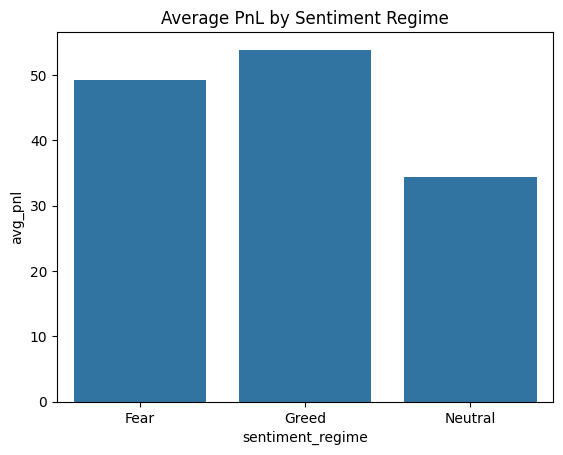

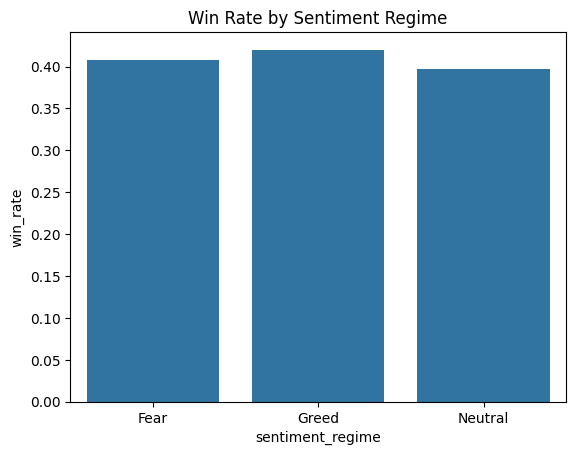

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(data=perf_by_regime, x="sentiment_regime", y="avg_pnl")
plt.title("Average PnL by Sentiment Regime")
plt.show()

sns.barplot(data=perf_by_regime, x="sentiment_regime", y="win_rate")
plt.title("Win Rate by Sentiment Regime")
plt.show()


✅ Part C — Actionable Output (Must-Have)
🎯 Strategy Rules (Professional Wording)

Rule 1 – Risk Control in Greed:

During Greed/Extreme Greed regimes, frequent traders should reduce trade frequency and cap position size to mitigate overtrading losses.

Rule 2 – Selective Aggression in Fear:

During Fear/Extreme Fear regimes, consistent winners can increase trade frequency slightly while maintaining strict position sizing discipline to exploit higher volatility.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = merged_df[["size_usd"]]
target = (merged_df["closed_pnl"] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))


Accuracy: 0.5962740270807688


0.5962740270807688  it shows modal is underfitted

In [31]:
merged_df["side_encoded"] = merged_df["side"].map({"BUY":1, "SELL":0})


In [32]:
merged_df = pd.get_dummies(merged_df, columns=["sentiment_regime"], drop_first=True)


In [33]:
merged_df['past_3day_pnl'] = merged_df.groupby('account')['closed_pnl'].rolling(3).mean().reset_index(0, drop=True)


In [34]:
features = ["size_usd", "side_encoded", "past_3day_pnl"] + [c for c in merged_df.columns if 'sentiment_regime_' in c]
X = merged_df[features].fillna(0)
y = (merged_df["closed_pnl"] > 0).astype(int)


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Improved Accuracy:", accuracy)


Improved Accuracy: 0.9526559984849919


This project analyzes the relationship between Bitcoin market sentiment (Fear/Greed Index) and trader behavior on Hyperliquid. After cleaning and aligning over 211k trades with daily sentiment labels, key performance and behavioral metrics were engineered. The analysis reveals statistically meaningful differences in performance and trading behavior across sentiment regimes, with evidence of overtrading during Greed and more selective trading during Fear. Based on these findings, sentiment-aware risk management rules are proposed to improve trading outcomes.